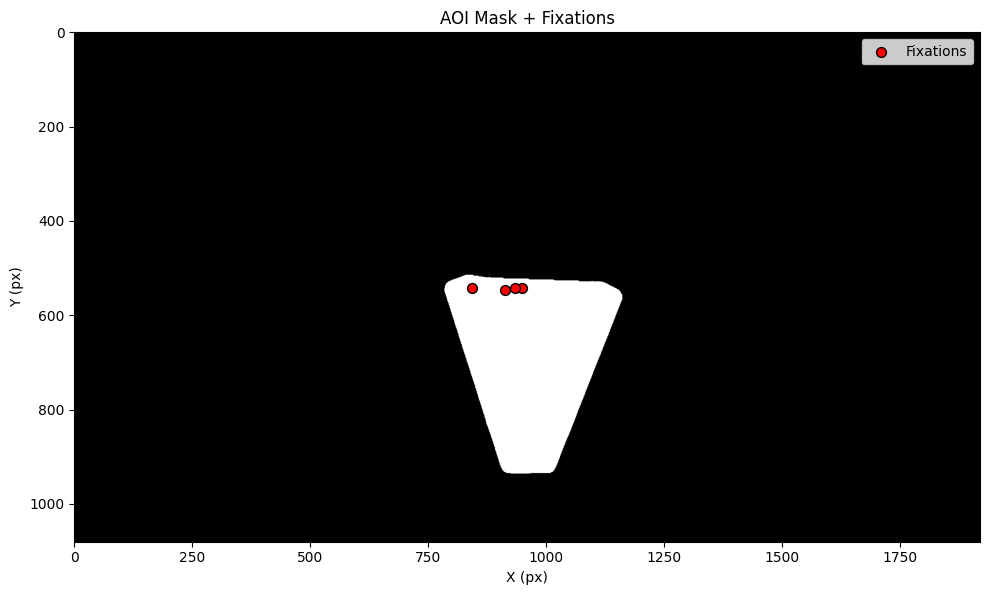

In [26]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# === ファイルパス（例） ===
aoi_image_path = "../face_aoi_project/output_aoi_triangle/1-1.jpg"
fixation_csv_path = "./exported_csv/fixation_IVT_split/fix_df_001-001-0_0.0-2.0.csv"

# === 読み込み ===
img = cv2.imread(aoi_image_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# マスク作成
lower_cyan = np.array([75, 20, 20])
upper_cyan = np.array([105, 255, 255])
mask = cv2.inRange(hsv, lower_cyan, upper_cyan)
# --- 輪郭抽出 ---
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# 空のマスクを用意し、塗りつぶす
filled_mask = np.zeros_like(mask)
cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

# fixation 読み込み
fixation_df = pd.read_csv(fixation_csv_path)
fixation_df = fixation_df.dropna(subset=["x_mean_px", "y_mean_px"])

# === プロット ===
plt.figure(figsize=(10, 6))

# マスク表示（白がAOI）
plt.imshow(filled_mask, cmap='gray', extent=[0, 1920, 1080, 0])

# 注視点をプロット
plt.scatter(
    fixation_df["x_mean_px"],
    fixation_df["y_mean_px"],
    c='red', edgecolors='black', label="Fixations", s=50
)

plt.title("AOI Mask + Fixations")
plt.xlabel("X (px)")
plt.ylabel("Y (px)")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
import cv2
import numpy as np
import pandas as pd
import os

# === 設定 ===
input_dir = "./exported_csv/fixation_IVT_split"
output_dir = "./exported_csv/fixation_IVT_split/fixation_with_AOI_labels"
aoi_dir = "../face_aoi_project/output_aoi_triangle"
interval = "0.0-2.0"

screen_width, screen_height = 1920, 1080  # ピクセル変換用

os.makedirs(output_dir, exist_ok=True)

for subject_id in range(1, 20):
    for experiment_id in range(1, 4):
        for trial_num in range(8):
            # === ファイルパス定義 ===
            fname = f"fix_df_{subject_id:03}-{experiment_id:03}-{trial_num}_{interval}.csv"
            fixation_csv_path = os.path.join(input_dir, fname)
            aoi_image_path = os.path.join(aoi_dir, f"{experiment_id}-{trial_num + 1}.jpg")
            output_csv_path = os.path.join(output_dir, f"fixation_AOI_label_{subject_id:03}-{experiment_id:03}-{trial_num}.csv")

            # AOI画像存在チェック
            if not os.path.exists(aoi_image_path):
                print(f"⚠️ AOI画像が存在しません: {aoi_image_path}")
                continue

            # 注視ファイルが存在しない → no_fixation と記録
            if not os.path.exists(fixation_csv_path):
                pd.DataFrame([{
                    "subject_id": subject_id,
                    "experiment_id": experiment_id,
                    "trial": trial_num,
                    "AOI_label": "no_fixation"
                }]).to_csv(output_csv_path, index=False, encoding="utf-8-sig")
                continue

            fixation_df = pd.read_csv(fixation_csv_path)
            if fixation_df.empty:
                pd.DataFrame([{
                    "subject_id": subject_id,
                    "experiment_id": experiment_id,
                    "trial": trial_num,
                    "AOI_label": "no_fixation"
                }]).to_csv(output_csv_path, index=False, encoding="utf-8-sig")
                continue

            # === AOI画像とマスク作成 ===
            img = cv2.imread(aoi_image_path)
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            lower_cyan = np.array([75, 20, 20])   # 調整可能
            upper_cyan = np.array([105, 255, 255])

            mask = cv2.inRange(hsv, lower_cyan, upper_cyan)
            
            # --- 輪郭抽出 ---
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            # 空のマスクを用意し、塗りつぶす
            filled_mask = np.zeros_like(mask)
            MASK = cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

            height, width = mask.shape[:2]
            labels = []

            for _, row in fixation_df.iterrows():
                if pd.isna(row["x_mean_px"]) or pd.isna(row["y_mean_px"]):
                    labels.append("outside")
                    continue

                x = int(np.clip(row["x_mean_px"], 0, width - 1))
                y = int(np.clip(row["y_mean_px"], 0, height - 1))

                if MASK[y, x] == 255:
                    labels.append("inside")
                else:
                    labels.append("outside")

            fixation_df["AOI_label"] = labels
            fixation_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")
            print(f"✅ 保存: {output_csv_path}")


✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-0.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-1.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-2.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-3.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-4.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-5.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-6.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-001-7.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-002-0.csv
✅ 保存: ./exported_csv/fixation_IVT_split/fixation_with_AOI_labels\fixation_AOI_label_001-002-1.csv
✅ 保存: ./exported_csv

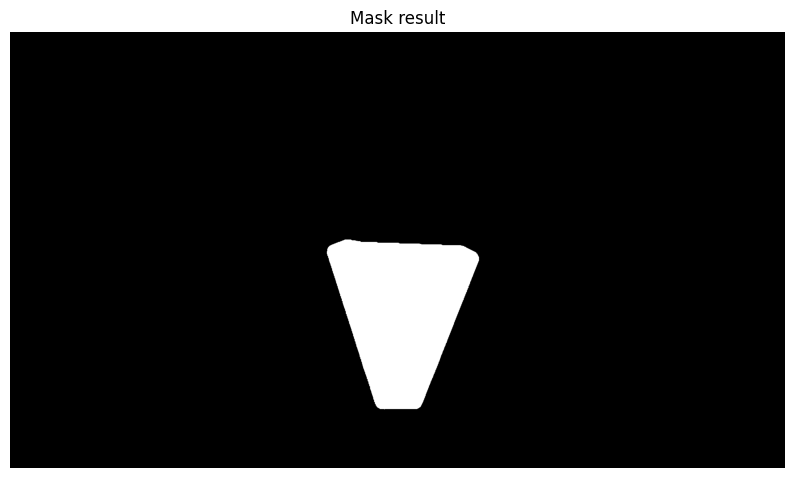

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# === 画像とマスクの読み込み ===
aoi_image_path = "../face_aoi_project/output_aoi_triangle/1-1.jpg"
csv_path = "./exported_csv/fixation_IVT_split/fix_df_001-001-0_0.0-2.0.csv"

img = cv2.imread(aoi_image_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# シアン色マスクのしきい値（必要なら調整）
lower_cyan = np.array([75, 30, 30])
upper_cyan = np.array([105, 255, 255])

mask = cv2.inRange(hsv, lower_cyan, upper_cyan)

# --- 輪郭抽出 ---
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 空のマスクを用意し、塗りつぶす
filled_mask = np.zeros_like(mask)
cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)

# filled_mask を以降のマスクとして使用
mask = filled_mask

# === マスク画像と注視点の表示 ===
plt.figure(figsize=(10, 6))
plt.imshow(mask, cmap='gray')
plt.title("Mask result")
plt.axis('off')
plt.show()


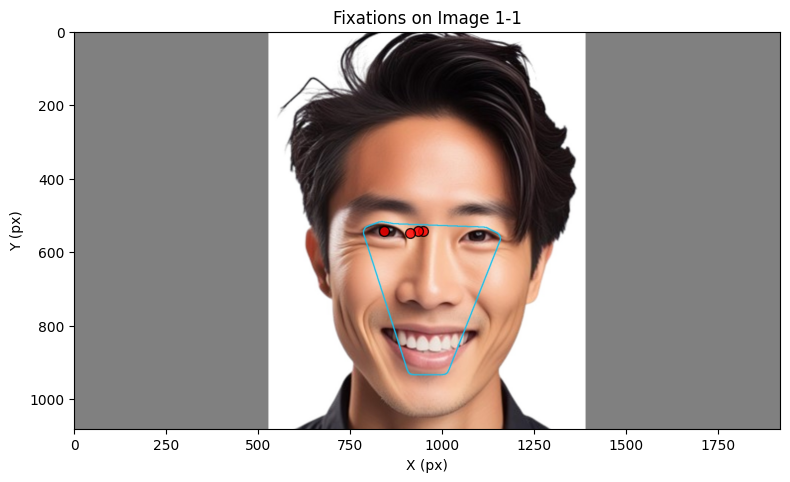

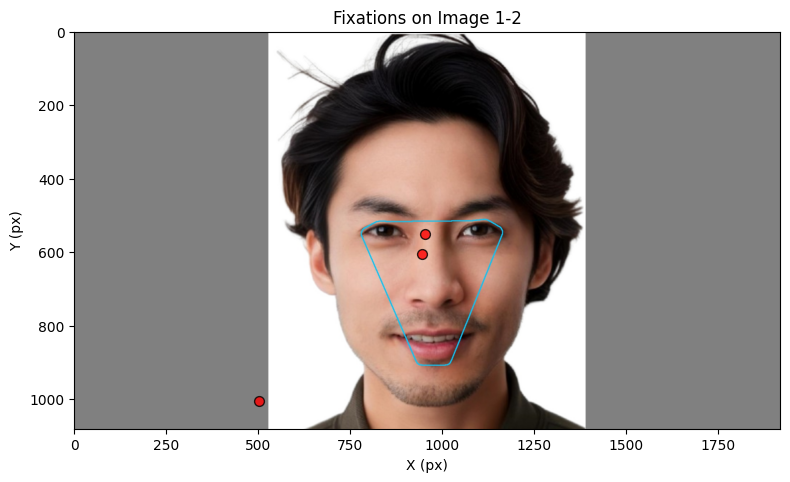

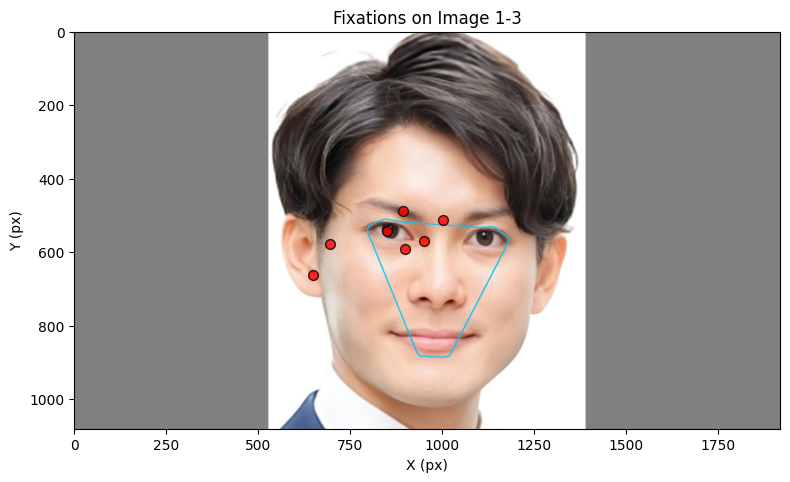

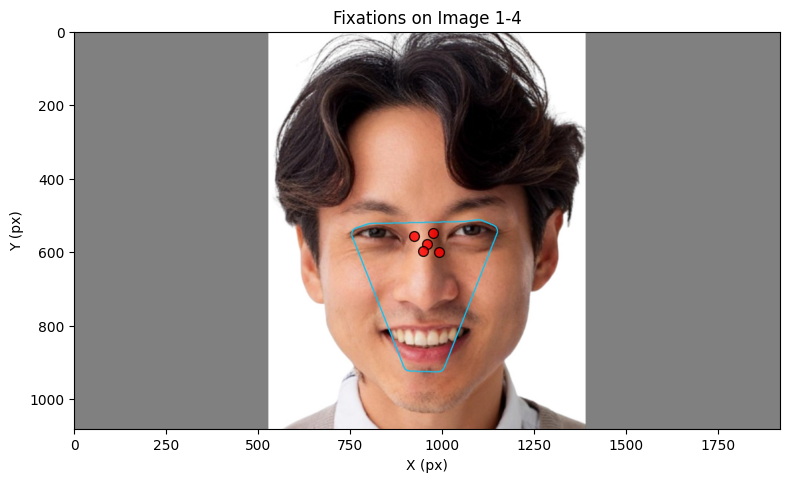

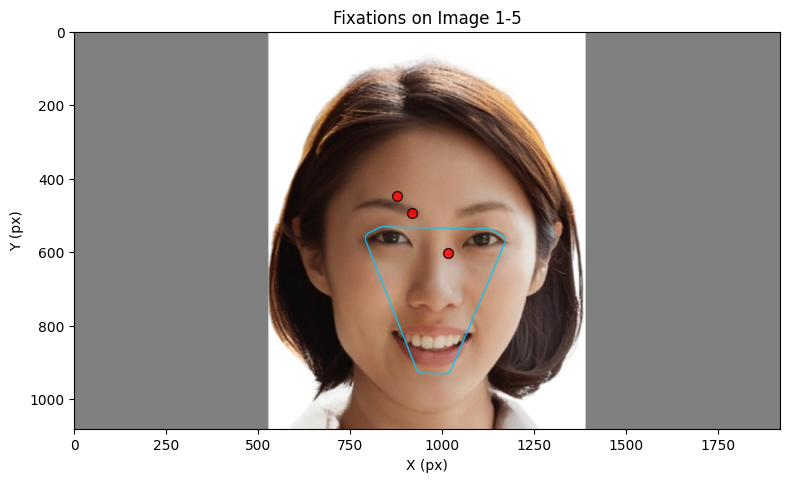

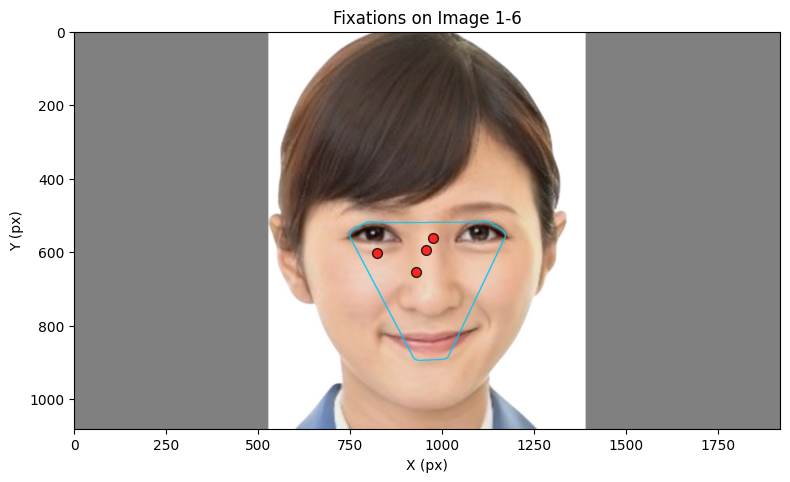

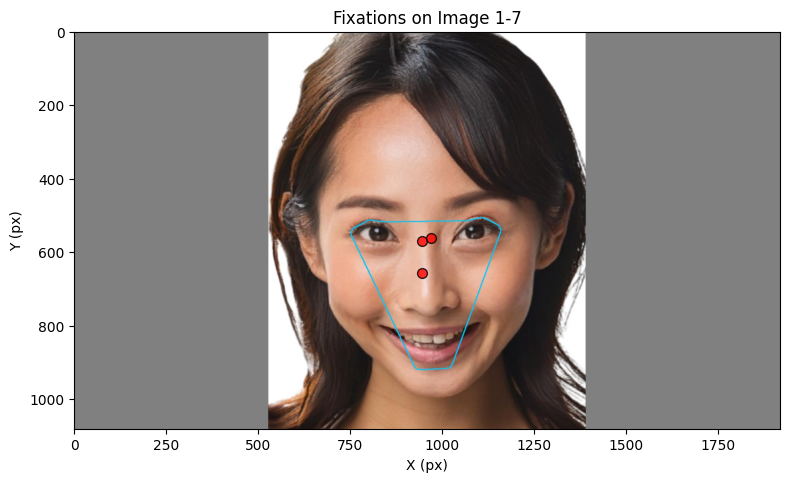

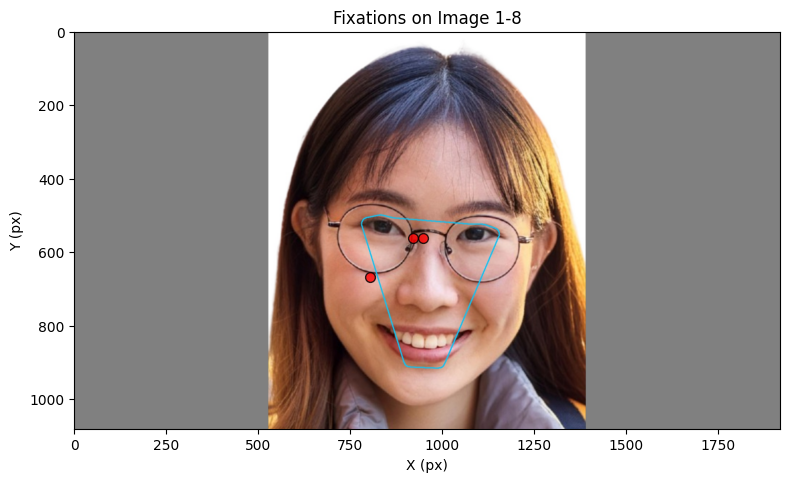

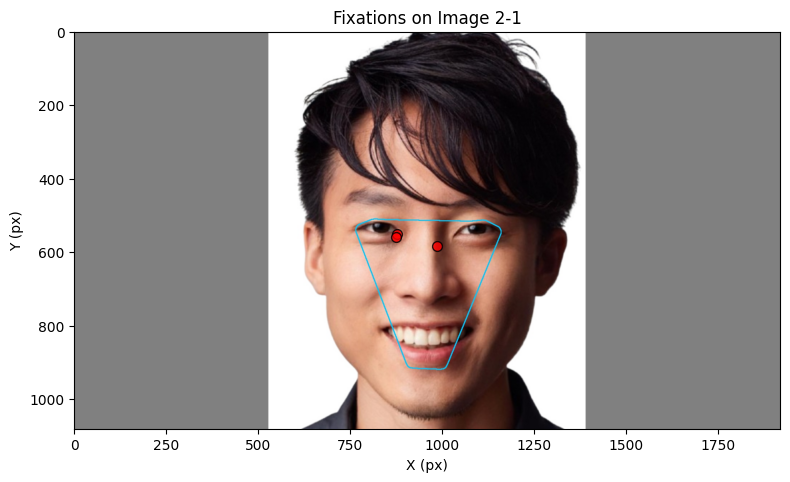

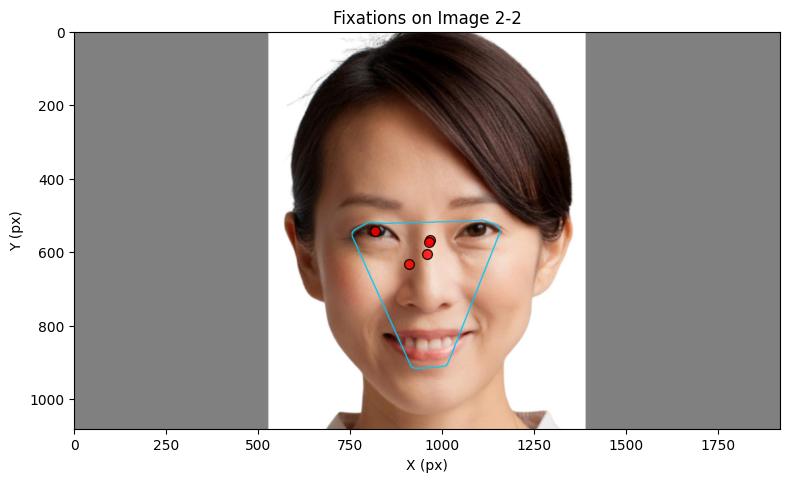

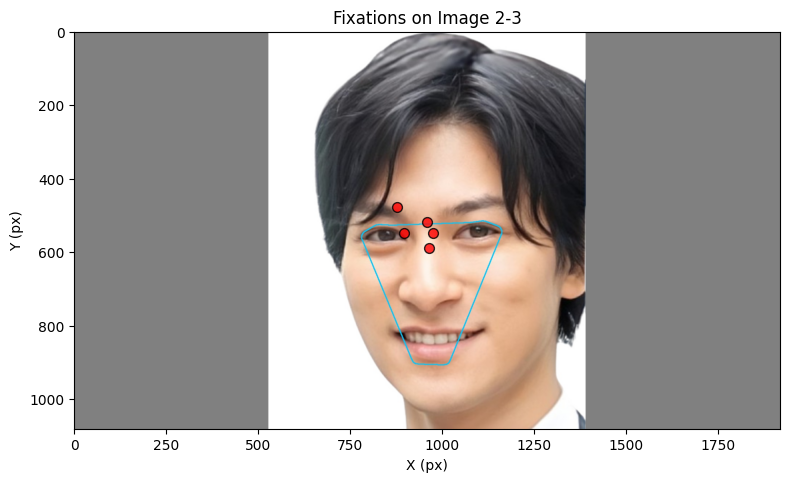

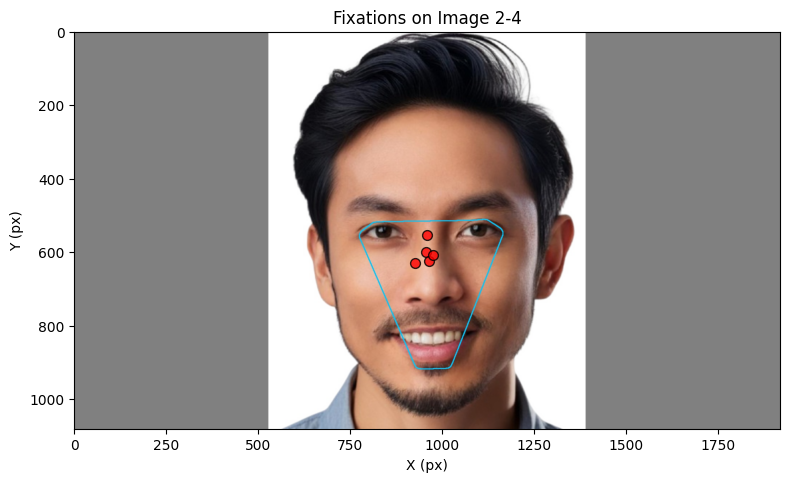

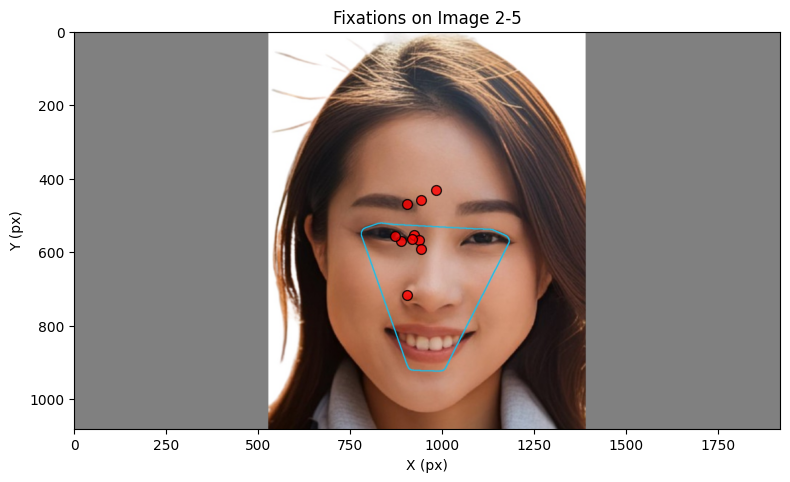

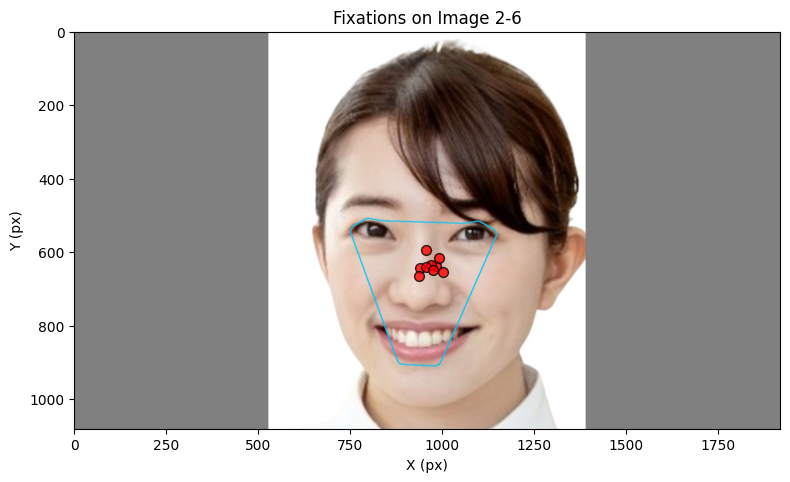

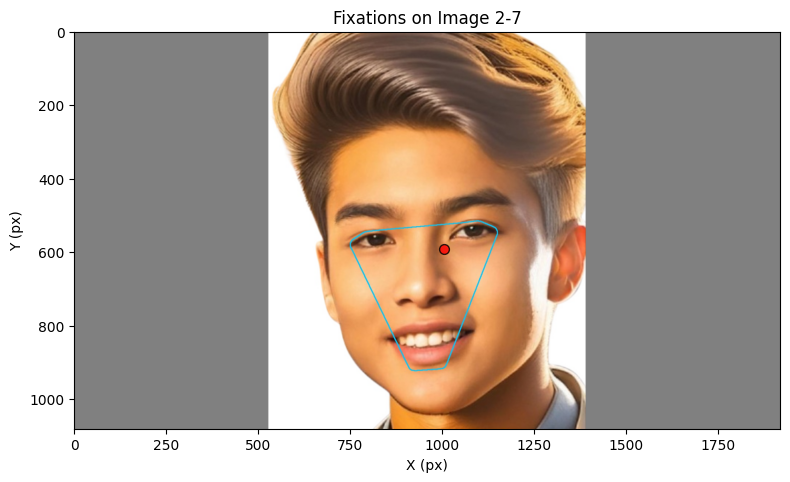

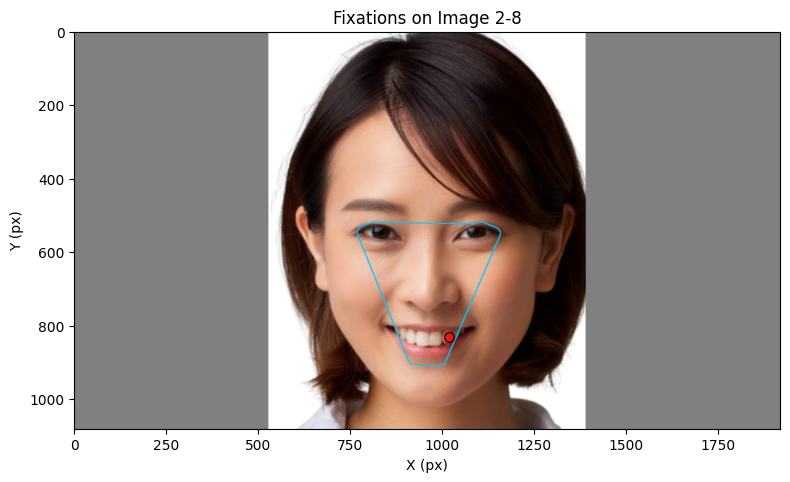

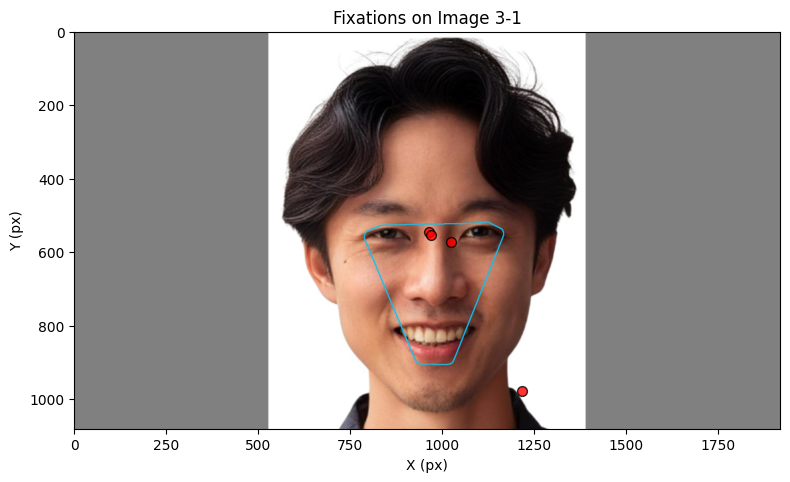

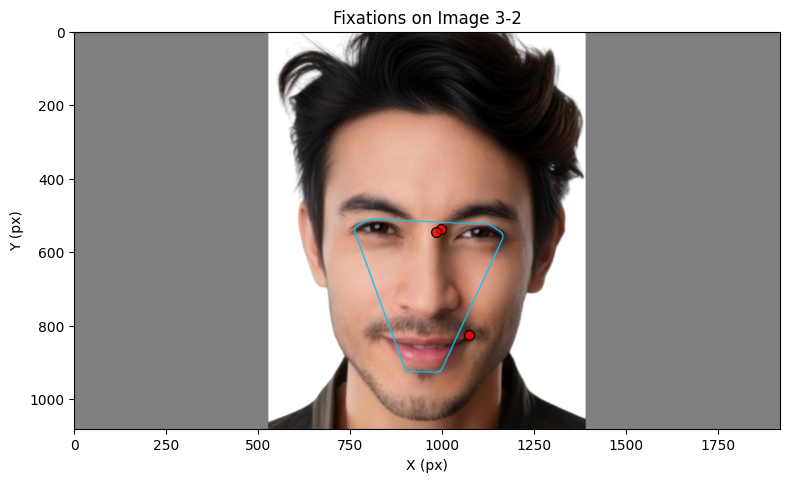

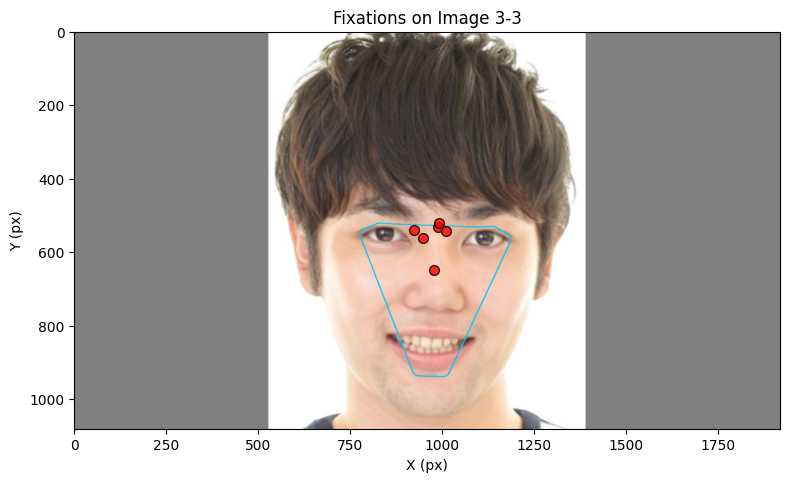

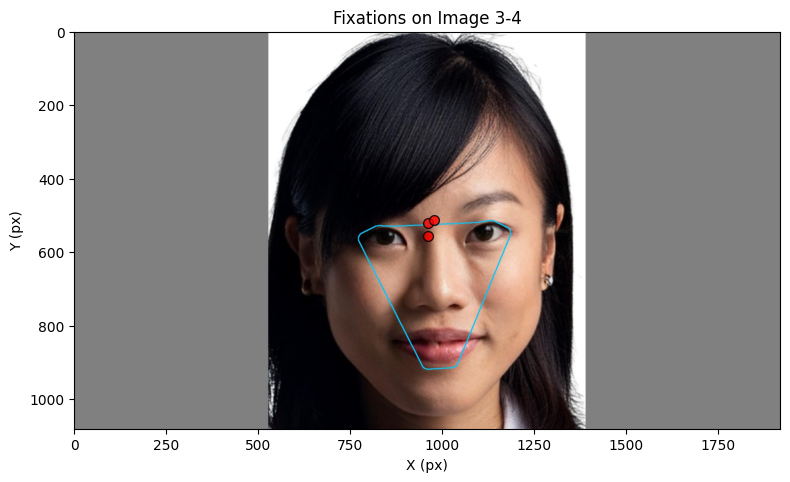

FileNotFoundError: [Errno 2] No such file or directory: './exported_csv/fixation_IVT_split/fix_df_001-003-4_0.0-2.0.csv'

In [ ]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# === 設定 ===
subject_id = 1
experiment_id = 1
trial_num = 0

screen_width, screen_height = 1920, 1080
aoi_dir = "../face_aoi_project/output_aoi_triangle"
fixation_path = f"./exported_csv/fixation_IVT_split/fix_df_{subject_id:03}-{experiment_id:03}-{trial_num}_0.0-2.0.csv"

# === AOI画像読み込み ===
image_path = os.path.join(aoi_dir, f"{experiment_id}-{trial_num+1}.jpg")
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"画像が見つかりません: {image_path}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === 注視データ読み込み ===
df = pd.read_csv(fixation_path)
df = df.dropna(subset=["x_mean_px", "y_mean_px"])

# === 散布図表示 ===
plt.figure(figsize=(8, 5))
plt.imshow(img_rgb, extent=[0, screen_width, screen_height, 0])  # 上下逆にしない
plt.scatter(df["x_mean_px"], df["y_mean_px"], c='red', s=50, edgecolors='black', alpha=0.8)

plt.title(f"Fixations on Image {experiment_id}-{trial_num+1}")
plt.xlabel("X (px)")
plt.ylabel("Y (px)")
plt.xlim(0, screen_width)
plt.ylim(0, screen_height)
plt.gca().invert_yaxis()
plt.grid(False)
plt.tight_layout()
plt.show()
